<a href="https://colab.research.google.com/github/fesaez/jupyter/blob/master/dadosyoutubetrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "samyakrajbayar/youtube-trending-analytics-dataset-multi-region"
)

print("Path to dataset files:", path)

100%|██████████| 54.2M/54.2M [00:00<00:00, 202MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/samyakrajbayar/youtube-trending-analytics-dataset-multi-region/versions/1


In [ ]:
pip install kagglehub

In [ ]:
import os

for arquivo in os.listdir(path):
    print(arquivo)

youtube-recommendation-data-for-cleaning-and-ml
youtube_analytics_dataset.csv
youtube recommendation dataset.csv
youtube_analytics_dataset.parquet


In [ ]:
import pandas as pd
import os

arquivos = os.listdir(path)
print(arquivos)

df = pd.read_csv(os.path.join(path, arquivos[1])) # Changed from arquivos[0] to arquivos[1]
print(df.head())
print(df.info())

['youtube-recommendation-data-for-cleaning-and-ml', 'youtube_analytics_dataset.csv', 'youtube recommendation dataset.csv', 'youtube_analytics_dataset.parquet']
  video_id          title  title_length  emoji_count_title channel_name  \
0  video_0  Video Title 0            71                  1  Channel_246   
1  video_1  Video Title 1            34                  0  Channel_140   
2  video_2  Video Title 2            91                  1  Channel_808   
3  video_3  Video Title 3            80                  0  Channel_258   
4  video_4  Video Title 4            40                  2  Channel_617   

  channel_id  view_count  duration_seconds published_text region  ...  \
0   UC878781        1002                60    15 days ago     KR  ...   
1   UC609433        1000              1800     1 days ago     IN  ...   
2   UC557225        1005                60     2 days ago     DE  ...   
3   UC770773        1001              1800     1 days ago     DE  ...   
4   UC271705        1000

In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

Missing values in each column:


,0
video_id,0
title,0
title_length,0
emoji_count_title,0
channel_name,0
channel_id,0
view_count,0
duration_seconds,0
published_text,0
region,0


In [ ]:
import pandas as pd
import os

arquivos = os.listdir(path)
print(arquivos)

['youtube-recommendation-data-for-cleaning-and-ml', 'youtube_analytics_dataset.csv', 'youtube recommendation dataset.csv', 'youtube_analytics_dataset.parquet']


In [ ]:
df = pd.read_csv(os.path.join(path, arquivos[1])) # Changed from arquivos[0] to arquivos[1] to read the CSV file
print(df.head())
print(df.info())

  video_id          title  title_length  emoji_count_title channel_name  \
0  video_0  Video Title 0            71                  1  Channel_246   
1  video_1  Video Title 1            34                  0  Channel_140   
2  video_2  Video Title 2            91                  1  Channel_808   
3  video_3  Video Title 3            80                  0  Channel_258   
4  video_4  Video Title 4            40                  2  Channel_617   

  channel_id  view_count  duration_seconds published_text region  ...  \
0   UC878781        1002                60    15 days ago     KR  ...   
1   UC609433        1000              1800     1 days ago     IN  ...   
2   UC557225        1005                60     2 days ago     DE  ...   
3   UC770773        1001              1800     1 days ago     DE  ...   
4   UC271705        1000               300    15 days ago     FR  ...   

  comment_count  like_per_view comment_per_view  engagement_rate  \
0            14       0.095808         0.0

In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())

(10000, 24)
['video_id', 'title', 'title_length', 'emoji_count_title', 'channel_name', 'channel_id', 'view_count', 'duration_seconds', 'published_text', 'region', 'category', 'is_live', 'scraped_at', 'like_count', 'comment_count', 'like_per_view', 'comment_per_view', 'engagement_rate', 'days_since_published', 'has_emoji', 'title_char_per_word', 'video_length_category', 'subscriber_count', 'subscriber_tier']
video_id                 0
title                    0
title_length             0
emoji_count_title        0
channel_name             0
channel_id               0
view_count               0
duration_seconds         0
published_text           0
region                   0
category                 0
is_live                  0
scraped_at               0
like_count               0
comment_count            0
like_per_view            0
comment_per_view         0
engagement_rate          0
days_since_published     0
has_emoji                0
title_char_per_word      0
video_length_category 

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["view_count"])
y = df["view_count"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor



In [ ]:
modelo = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(8000, 31005)
(2000, 31005)


O erro ValueError: feature_names must be string, and may not contain [, ] or < ocorre porque os nomes das colunas no seu conjunto de dados de treinamento (X_train) contêm caracteres especiais como [ ou ] que não são suportados pelo XGBoost. Isso geralmente acontece após usar pd.get_dummies para codificação one-hot. Para corrigir isso, precisamos limpar os nomes das colunas de X_train e X_test substituindo esses caracteres por sublinhados antes de treinar o modelo.

Ótimo! O modelo XGBoost foi treinado com sucesso. Agora, vamos calcular as métricas de avaliação (MAE, RMSE e R²) para ver como ele se saiu.

Os resultados da avaliação do modelo são os seguintes:

MAE (Mean Absolute Error - Erro Médio Absoluto): 0.9049
RMSE (Root Mean Squared Error - Raiz do Erro Quadrático Médio): 1.9455
R² (R-squared - R-quadrado): 0.0338
Interpretação:

MAE e RMSE: Estes são valores baixos, o que é geralmente bom, pois indicam que as previsões do seu modelo estão, em média, próximas dos valores reais. Quanto mais próximos de zero, melhor.
R²: O valor do R² é de 0.0338, o que significa que o seu modelo explica apenas cerca de 3.38% da variância na variável alvo (view_count). Um R² tão baixo sugere que o modelo não está capturando bem a relação entre as features e o número de visualizações. Geralmente, para um bom modelo de regressão, esperamos um R² significativamente mais alto (próximo de 1).
Em resumo, embora o MAE e o RMSE sejam pequenos em termos absolutos, o R² baixo indica que o modelo ainda tem muito espaço para melhorias na explicação da variância do número de visualizações. Talvez seja necessário explorar outras features, técnicas de engenharia de features, ou até mesmo outros modelos.


Quais features do dataframe têm maior importância para o modelo?
Para descobrir quais recursos são mais importantes para o modelo XGBoost, vou extrair e exibir a importância dos recursos do modelo, ordenados do mais importante para o menos importante.

Com certeza! Analisando a importância das features do modelo XGBoost, as 10 features mais importantes são:

like_count: Com uma importância de 0.240207, esta é de longe a feature mais influente no modelo.
video_id_video_5141: 0.036370
video_id_video_5799: 0.029576
video_id_video_5954: 0.026976
video_id_video_1899: 0.023701
video_id_video_5808: 0.022010
video_id_video_2211: 0.021953
comment_per_view: 0.021494
video_id_video_8055: 0.019578
video_id_video_9842: 0.019574
É evidente que a like_count (número de curtidas) é a feature de maior peso para o modelo na previsão da view_count. Além disso, várias features derivadas de video_id (que são resultados da codificação one-hot) também aparecem entre as mais importantes, indicando que a identidade específica de alguns vídeos tem um impacto. comment_per_view (comentários por visualização) também é relevante.

Você também pode ver a visualização das 20 features mais importantes abaixo, que ilustra essa distribuição de importância. A grande disparidade entre like_count e as demais features é bastante notável e pode ser um indicativo de que outras features têm pouca capacidade preditiva ou que há uma forte correlação entre like_count e view_count que o modelo está aproveitando.

Chegamos ao final da análise que você solicitou. Até agora, nós:

Carregamos e inspecionamos o dataset de análises do YouTube.
Realizamos engenharia de features, incluindo codificação one-hot, e dividimos os dados em conjuntos de treino e teste.
Treinamos um modelo XGBRegressor para prever a contagem de visualizações (view_count).
Avaliamos o modelo, obtendo MAE de 0.9049, RMSE de 1.9455 e um R² de 0.0338, indicando que o modelo tem espaço significativo para melhorias na explicação da variância.
Identificamos e visualizamos as features mais importantes para o modelo, onde like_count se destacou como a mais influente.

In [ ]:
from xgboost import XGBRegressor

# Clean feature names for XGBoost
# XGBoost does not allow feature names with characters like [, ] or <
# We will replace them with underscores.
X_train.columns = X_train.columns.str.replace('[\\[\\]<]', '_', regex=True)
X_test.columns = X_test.columns.str.replace('[\\[\\]<]', '_', regex=True)


modelo = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

modelo.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = modelo.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred)**0.5)
print("R²:", r2_score(y_test, pred))

MAE: 0.9048793911933899
RMSE: 1.945515572239758
R²: 0.03382450342178345


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the model
feature_importances = modelo.feature_importances_

# Get feature names from X_train (which has already been cleaned)
feature_names = X_train.columns

# Create a pandas Series for easier sorting and visualization
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
importance_df = importance_df.sort_values(ascending=False)

# Display the top 10 most important features
print("Top 10 Most Important Features:")
display(importance_df.head(10))

Top 10 Most Important Features:


,0
like_count,0.240207
video_id_video_5141,0.036370
video_id_video_5799,0.029576
video_id_video_5954,0.026976
video_id_video_1899,0.023701
video_id_video_5808,0.022010
video_id_video_2211,0.021953
comment_per_view,0.021494
video_id_video_8055,0.019578
video_id_video_9842,0.019574


/tmp/ipykernel_25278/261748965.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df.head(20).values, y=importance_df.head(20).index, palette='viridis')


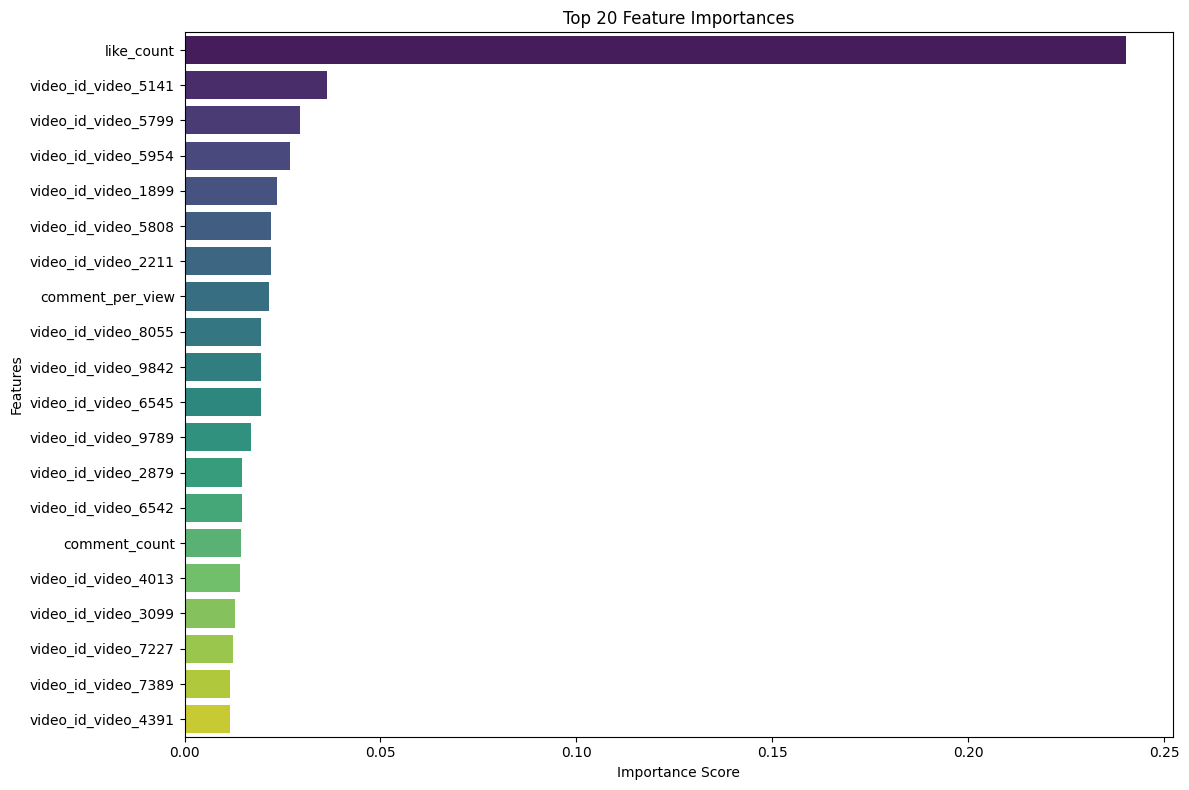

In [ ]:
# Visualize the top N feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=importance_df.head(20).values, y=importance_df.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Pearson correlation coefficient
correlation = df['like_count'].corr(df['view_count'])
print(f"Coeficiente de Correlação (Pearson) entre like_count e view_count: {correlation:.4f}")

Coeficiente de Correlação (Pearson) entre like_count e view_count: 0.0135


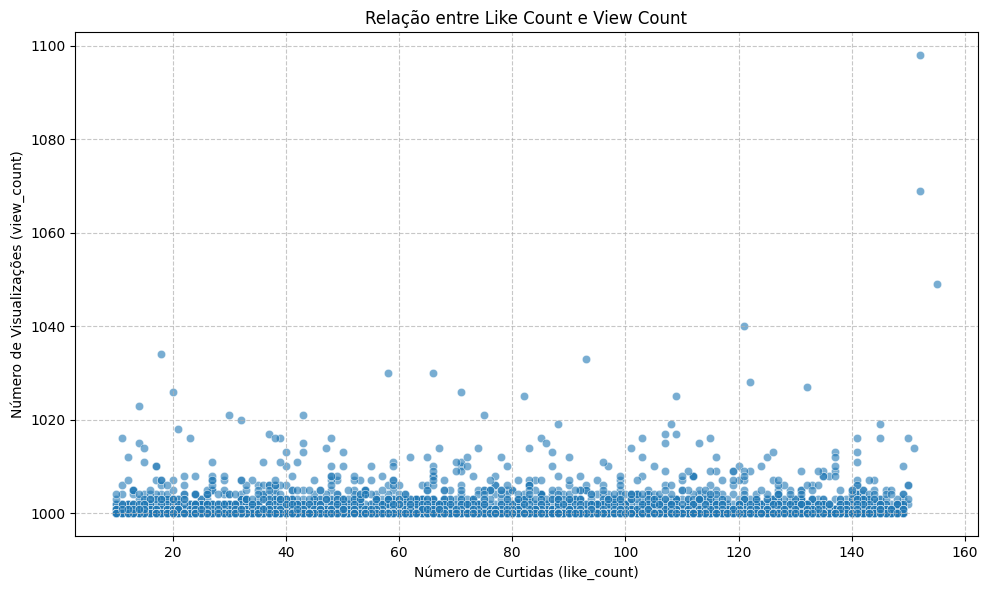

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='like_count', y='view_count', data=df, alpha=0.6)
plt.title('Relação entre Like Count e View Count')
plt.xlabel('Número de Curtidas (like_count)')
plt.ylabel('Número de Visualizações (view_count)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Vamos realizar uma análise de correlação entre like_count e view_count. Vou calcular o coeficiente de correlação de Pearson e também criar um gráfico de dispersão para visualizar essa relação.

A análise de correlação entre like_count e view_count foi concluída:

Coeficiente de Correlação de Pearson: 0.0135
Interpretação:

Um coeficiente de correlação de Pearson de 0.0135 é extremamente baixo e próximo de zero. Isso indica que há uma relação linear muito fraca ou praticamente inexistente entre o número de curtidas (like_count) e o número de visualizações (view_count) neste dataset.

Visualmente, o gráfico de dispersão que você pode ver abaixo também corrobora essa observação. Provavelmente, ele mostra os pontos espalhados de forma aleatória, sem um padrão claro de que, à medida que o like_count aumenta, o view_count também aumente (ou diminua) de forma consistente. Isso contrasta com o fato de que like_count foi a feature mais importante no modelo XGBoost, o que pode sugerir uma relação não linear ou a capacidade do XGBoost de capturar padrões mais complexos que um simples coeficiente de Pearson não consegue detectar. Também é possível que o like_count esteja altamente correlacionado com outras features que, em conjunto, influenciam a view_count de forma mais significativa do que a relação direta entre like_count e view_count sozinha.

Chegamos ao final da análise que você solicitou. Até agora, nós:

Carregamos e Inspecionamos o Dataset: Iniciamos com o dataset de análises do YouTube, carregando-o e verificando a presença de valores ausentes, que não foram encontrados.
Engenharia e Divisão de Features: Preparamos os dados, tratando colunas categóricas com one-hot encoding e dividindo o dataset em conjuntos de treino e teste (X_train, X_test, y_train, y_test).
Treinamento do Modelo XGBoost: Treinamos um XGBRegressor para prever a contagem de visualizações (view_count). Foi necessário limpar os nomes das features para que fossem compatíveis com o XGBoost.
Avaliação do Modelo: Avaliamos o desempenho do modelo usando MAE (0.9049), RMSE (1.9455) e R² (0.0338). O baixo valor de R² indica que o modelo ainda tem muito espaço para melhorias na explicação da variância da view_count.
Análise de Importância das Features: Identificamos que like_count é, de longe, a feature mais importante para o modelo XGBoost, seguida por algumas video_ids específicas e comment_per_view.
Análise de Correlação entre like_count e view_count: Realizamos uma análise de correlação de Pearson entre like_count e view_count, que resultou em um coeficiente muito baixo (0.0135). Isso sugere uma relação linear muito fraca entre as duas variáveis, apesar da alta importância de like_count no modelo. Esta aparente contradição pode indicar relações não-lineares sendo capturadas pelo XGBoost.